# Elastic plotting tutorial

This tutorial was prepared by Alexandre Olender: olender@usp.br

This tutorial demonstrates some of Spiro's plotting utilities for the isotropic elastic wave problem.

We will visualize:
1. The displacement wavefield at a given timestep;
2. An individual receiver trace for displacement in each direction;
3. A complete shot record.

In [12]:
# Code in this cell enables plotting in the notebook
%matplotlib inline

import spyro
import numpy as np
import matplotlib.pyplot as plt

Let us begin by setting up an isotropic elastic forward problem in Spiro. We will focus on the homogeneous case for this tutorial.

In [13]:
vp = 1.5
vs = 1.0
rho = 0.1

We will use elements that are 0.1 km (or 100 meter) wide.

In [ ]:
edge_length = 0.1
source_z = -1.1
receiver_z = -1.9
receiver_locations = spyro.create_transect((receiver_z, 1.2), (receiver_z, 1.8), 300)

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 3.0,
        "length_x": 3.0,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [(source_z, 1.5)],
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": 1.5,
        "dt": 0.001,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}

dictionary["synthetic_data"] = {
    "type": "object",
    "density": rho,
    "p_wave_velocity": vp,
    "s_wave_velocity": vs,
    "real_velocity_file": None,
}
wave = spyro.IsotropicWave(dictionary)
wave.set_mesh(input_mesh_parameters={"edge_length": edge_length, "periodic": False})


Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.
Mesh Created with 961 Nodes and 900 Area Elements


/workspaces/qol_upgrades/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


We can have a quick look at our mesh using Firedrake's pyplot wrappers:

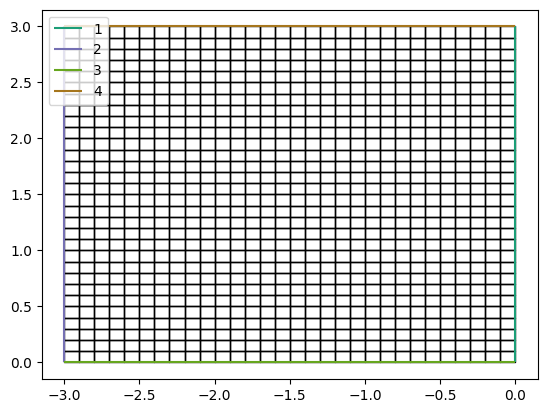

In [15]:
from firedrake.pyplot import triplot
fig, axes = plt.subplots()
triplot(wave.mesh, axes=axes)
axes.legend();


Let us propagate our wave and look at the last result.

In [16]:
wave.forward_solve()


Solving Forward Problem
Simulation time is:        0.0 seconds


/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds
Simulation time is:        0.9 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.1 seconds
Simulation time is:        1.2 seconds
Simulation time is:        1.3 seconds
Simulation time is:        1.4 seconds
Simulation time is:        1.5 seconds


In the elastic problem, ``wave.u_n`` is a vector-valued function:
```
    u_z = u_n.sub(0)
    u_x = u_n.sub(1)
```

where ``u_z`` and ``u_x`` are the vertical and horizontal displacement
components, respectively.

To visualize one component, we extract it from the vector-valued
function before plotting. Before using Spiro's higher-resolution plotting utilities, we can
quickly inspect it using Firedrake's standard plotting functionality.

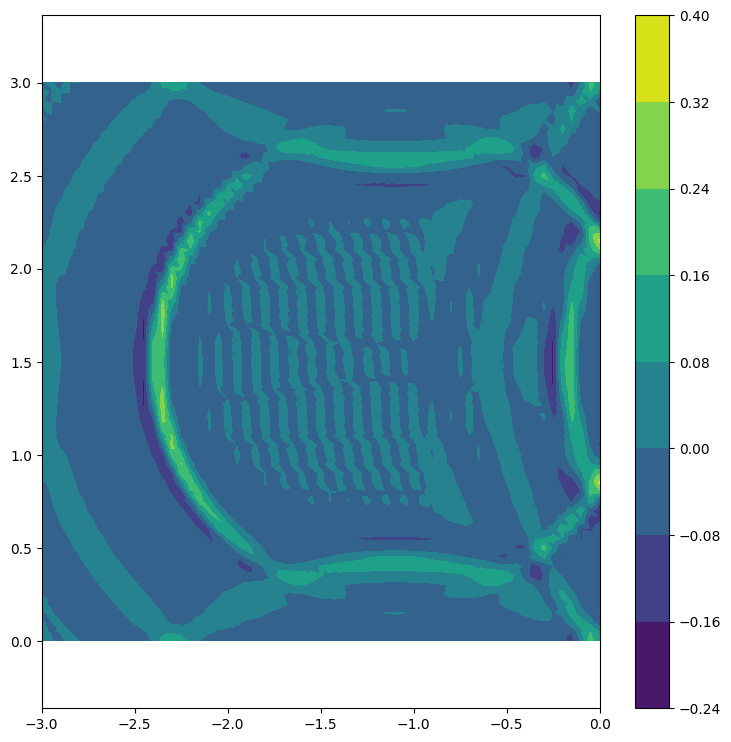

In [17]:
spyro.plots.plot_function(wave.u_n.sub(1))

This quick visualization image has some problems:
* We are seeing a lot of mesh artifacts, therefore we could increase the resolution using
`spyro.io.export_scalar_field`.
* There's significant reflection from the boundaries, so we either add an absorbing boundary of some kind or increase mesh size and reposition our acquisition geometry so this reflection does not show up during our simulation time.

## 1. Displacement wavefield

Let us visualize it with a higher resolution

/usr/local/lib/python3.12/dist-packages/segyio/utils.py:18: RuntimeWarning: Implicit conversion to contiguous array
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/segyio/utils.py:23: RuntimeWarning: Implicit conversion from float64 to float32 (narrowing)
  warnings.warn(msg.format(x.dtype, dtype), RuntimeWarning)


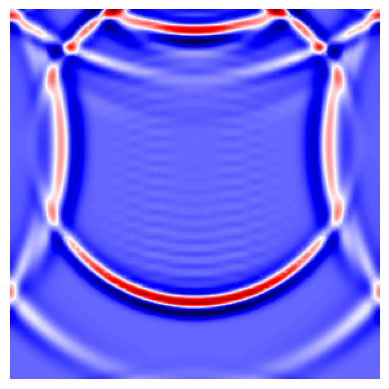

In [18]:
resolution = 0.01
spyro.io.export_scalar_field(wave.u_n.sub(1), resolution, "last_wavefield.png", comm=wave.comm, show=True, aspect="equal")

## 2. Individual receiver trace

We can inspect the displacement components recorded at an individual receiver. Here we plot the horizontal and vertical displacement at receiver 0.

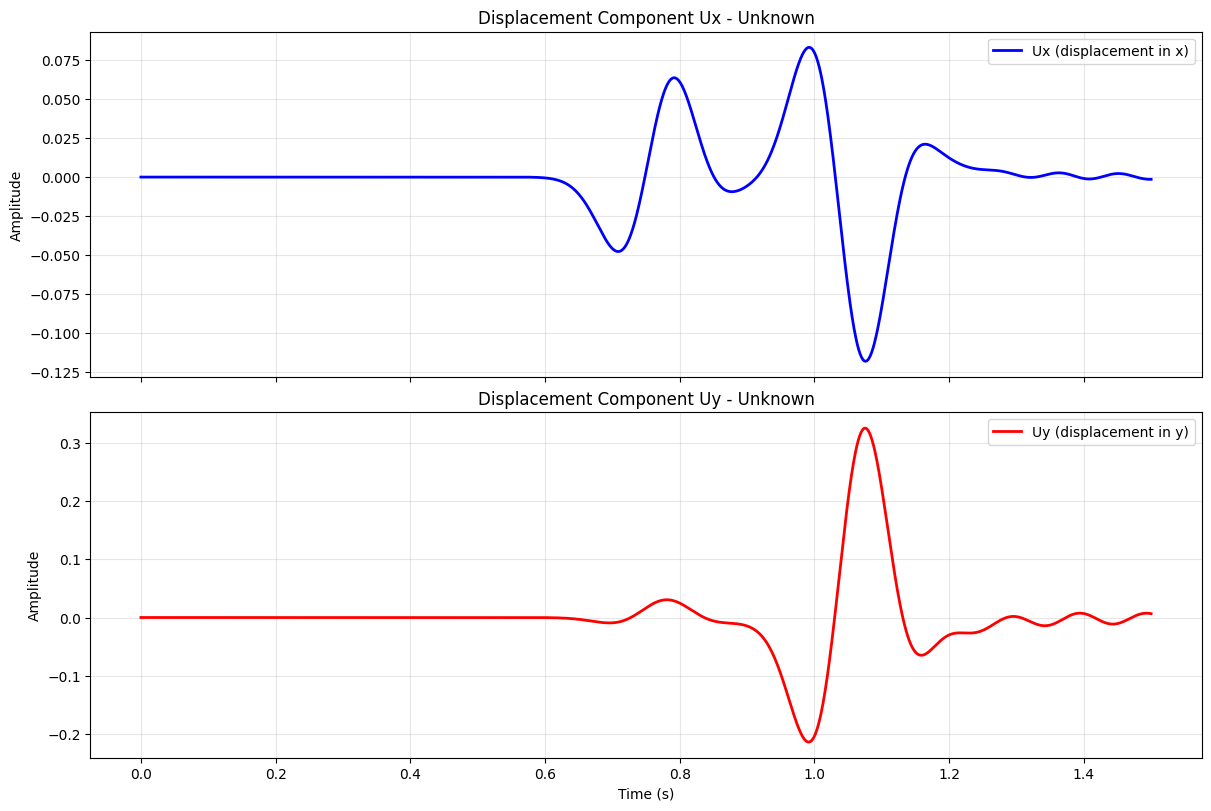

In [19]:
time_vector = spyro.utils.get_time_vector(wave)
spyro.plots.plot_displacement_components(time_vector, wave.forward_solution_receivers[:, 0, :])

## 3. A complete shot record.

We can also look at a shot record:

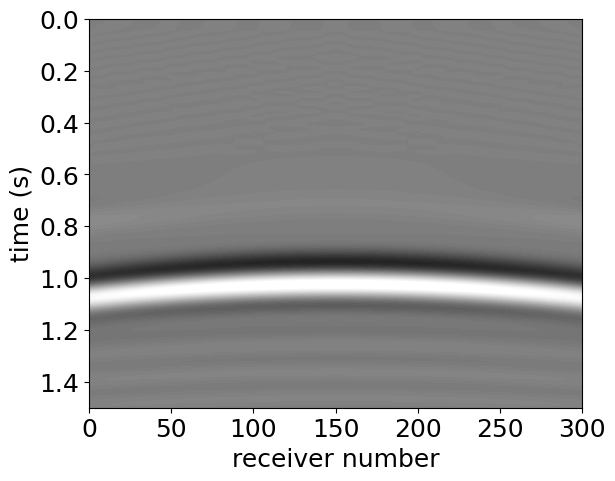

In [20]:
last_displacement = wave.u_n.dat.data[:]
u_max = np.max(np.abs(last_displacement[:, 1]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=1)